In [17]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.size'] = 12

## Loading behavioural data

In [18]:
import pandas as pd
# Load the Psilocybin Output Excel file
# index_col=0 sets the first column as the index (row names)
# header=0 sets the first row as the column names (this is the default behavior)
behavioural_data = pd.read_excel('BehaviouralData/CB_PsyHC_Motor.xlsx')




# Replace the subject column values
behavioural_data['Subject'] = behavioural_data['Subject'].str.replace(r'^Psy_HC_', 'HC', regex=True)
behavioural_data['Timepoint'] = behavioural_data['Timepoint'].str.replace(r'90min', '1.5h', regex=True)
behavioural_data.head()

,Subject,Timepoint,DEMMI,Functional Movement Exploration,ARAT,Box and Block (standard),Box and Block (modified),Reaction Time (cm),DSST,DSST.1
0,HC01,Baseline,100,NaN,57,80,54,22.000000,81,77
1,HC01,5mg-1.5h,100,NaN,57,85,48,16.666666,80,90
2,HC01,5mg-3h,100,NaN,57,82,51,18.666666,90,67
3,HC01,5mg-4.5h,100,NaN,57,83,53,13.000000,90,82
4,HC01,10mg-1.5h,100,NaN,56,73,50,20.000000,71,65


In [19]:
behavioural_data[behavioural_data['Box and Block (standard)']==0]

,Subject,Timepoint,DEMMI,Functional Movement Exploration,ARAT,Box and Block (standard),Box and Block (modified),Reaction Time (cm),DSST,DSST.1
59,HC08,20mg-3h,0,0.0,0,0,0,31.0,0,74


<Axes: >

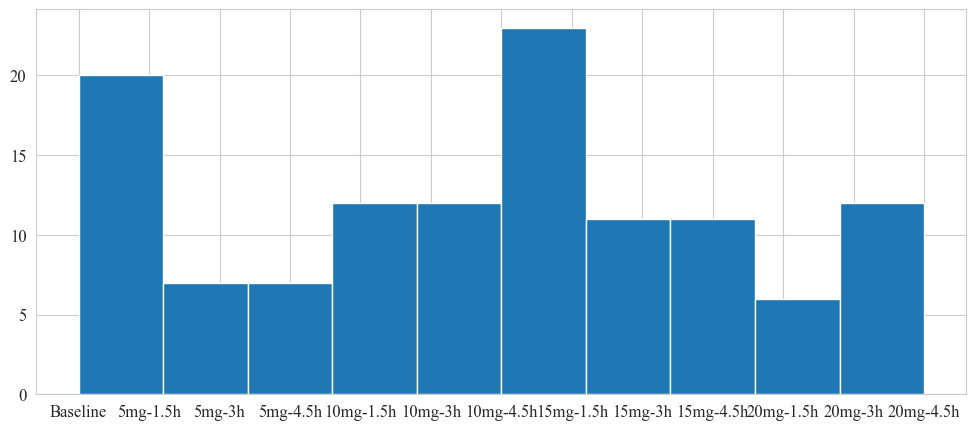

In [20]:

behavioural_data['Timepoint'].hist(figsize=(12,5))


In [21]:
dose_order_data = pd.read_excel('BehaviouralData/hc_randomisation.xlsx')
dose_order_data['ppt_id'] = dose_order_data['ppt_id'].str.replace(r'^Psy_HC_', 'HC', regex=True)
dose_order_data[dose_order_data['dose_alc_manual'].str.contains('20mg')]

,ppt_id,dose_alc_manual
6,HC08,"1st = 15mg, 2nd = 20mg, 3rd = 10mg (3)"
8,HC10,"1st = 10mg, 2nd = 20mg, 3rd = 15mg (6)"
9,HC11,"1st = 20mg, 2nd = 15mg, 3rd = 10mg (5)"
10,HC12,"1st = 20mg, 2nd = 10mg, 3rd = 15mg (1)"
11,HC13,"1st = 15mg, 2nd = 10mg, 3rd = 20mg (4)"
12,HC14,"1st = 10mg, 2nd = 15mg, 3rd = 20mg (2)"


## Box and Block analysis

In [22]:
import re
import numpy as np

# Build a cleaned table (one row per Subject x Timepoint) with parsed dose and hour info

df = behavioural_data.copy()

def parse_timepoint(tp):
    if pd.isnull(tp) or 'Baseline' in str(tp):
        return pd.Series({'dose_mg': 0, 'dose_hr': np.nan, 'Condition': 'Baseline'})
    tp = str(tp)
    m = re.search(r'(\d{1,2})mg', tp)
    h = re.search(r'(\d+(?:\.\d+)?)h', tp)
    dose_mg = int(m.group(1)) if m else np.nan
    dose_hr = float(h.group(1)) if h else np.nan
    return pd.Series({'dose_mg': dose_mg, 'dose_hr': dose_hr, 'Condition': 'Dose'})

df[['dose_mg', 'dose_hr', 'Condition']] = df['Timepoint'].apply(parse_timepoint)

# Attach manual dose-order info (if available)
dose_order_map = dict(zip(dose_order_data['ppt_id'], dose_order_data['dose_alc_manual']))
df['dose_order'] = df['Subject'].map(dose_order_map)

# Select performance measures you want to keep here
measure_cols = [
    'Box and Block (standard)',
    'Box and Block (modified)',
    'Reaction Time (cm)',
    'DSST',
    'DEMMI',
    'ARAT'
]

# Create the results DataFrame and sort
bb_behavioural_results = df[['Subject', 'Timepoint', 'dose_mg', 'dose_hr', 'Condition', 'dose_order'] + measure_cols].copy()
bb_behavioural_results = bb_behavioural_results.sort_values(['Subject', 'dose_mg', 'dose_hr']).reset_index(drop=True)

# Quick check
bb_behavioural_results.head(10)


,Subject,Timepoint,dose_mg,dose_hr,Condition,dose_order,Box and Block (standard),Box and Block (modified),Reaction Time (cm),DSST,DEMMI,ARAT
0,HC01,Baseline,0,NaN,Baseline,"1st = 15mg, 2nd = 10mg, 3rd = 5mg (4)",80,54,22.000000,81,100,57
1,HC01,5mg-1.5h,5,1.5,Dose,"1st = 15mg, 2nd = 10mg, 3rd = 5mg (4)",85,48,16.666666,80,100,57
2,HC01,5mg-3h,5,3.0,Dose,"1st = 15mg, 2nd = 10mg, 3rd = 5mg (4)",82,51,18.666666,90,100,57
3,HC01,5mg-4.5h,5,4.5,Dose,"1st = 15mg, 2nd = 10mg, 3rd = 5mg (4)",83,53,13.000000,90,100,57
4,HC01,10mg-1.5h,10,1.5,Dose,"1st = 15mg, 2nd = 10mg, 3rd = 5mg (4)",73,50,20.000000,71,100,56
5,HC01,10mg-3h,10,3.0,Dose,"1st = 15mg, 2nd = 10mg, 3rd = 5mg (4)",84,49,18.000000,77,100,52
6,HC01,10mg-4.5h,10,4.5,Dose,"1st = 15mg, 2nd = 10mg, 3rd = 5mg (4)",89,46,20.000000,84,100,57
7,HC01,15mg-1.5h,15,1.5,Dose,"1st = 15mg, 2nd = 10mg, 3rd = 5mg (4)",73,50,23.000000,71,100,55
8,HC01,15mg-3h,15,3.0,Dose,"1st = 15mg, 2nd = 10mg, 3rd = 5mg (4)",70,45,14.333333,67,85,57
9,HC01,15mg-4.5h,15,4.5,Dose,"1st = 15mg, 2nd = 10mg, 3rd = 5mg (4)",79,45,20.333334,79,100,57


In [23]:
bb_behavioural_results.to_csv('bb_behavioural_results.csv', index=False)

### Average effects

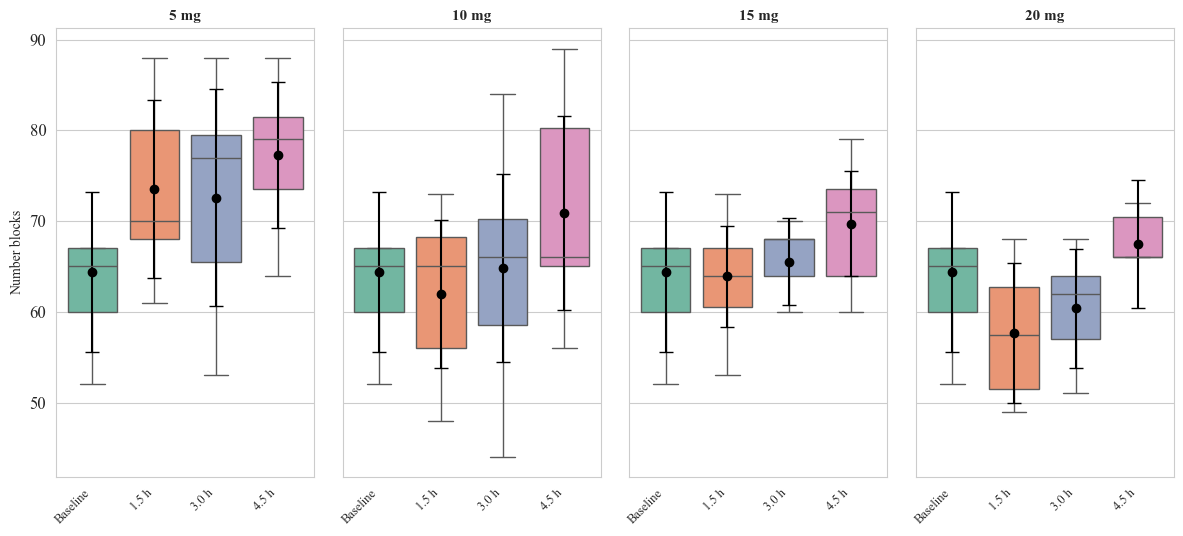

Participants included across doses for Box and Block (standard): []
The following participants had no positive Box and Block (standard) observations and were excluded entirely: ['HC01', 'HC02', 'HC03', 'HC04', 'HC05', 'HC06', 'HC08', 'HC09', 'HC10', 'HC11', 'HC12', 'HC13', 'HC14']

Sessions excluded because target variable was zero or non-positive (per dose):
- Dose 20 mg (Box and Block (standard)):
Subject Timepoint  dose_mg  Box and Block (standard)
   HC08   20mg-3h       20                         0

DATA POINTS PER BOXPLOT FOR: Box and Block (standard)
Dose (mg)    5     10    15    20
Timepoint                        
1.5 h       7.0  12.0  11.0   6.0
3.0 h       7.0  12.0  11.0   5.0
4.5 h       7.0  12.0  11.0   6.0
Baseline   13.0  13.0  13.0  13.0

Total data points for Box and Block (standard): 159



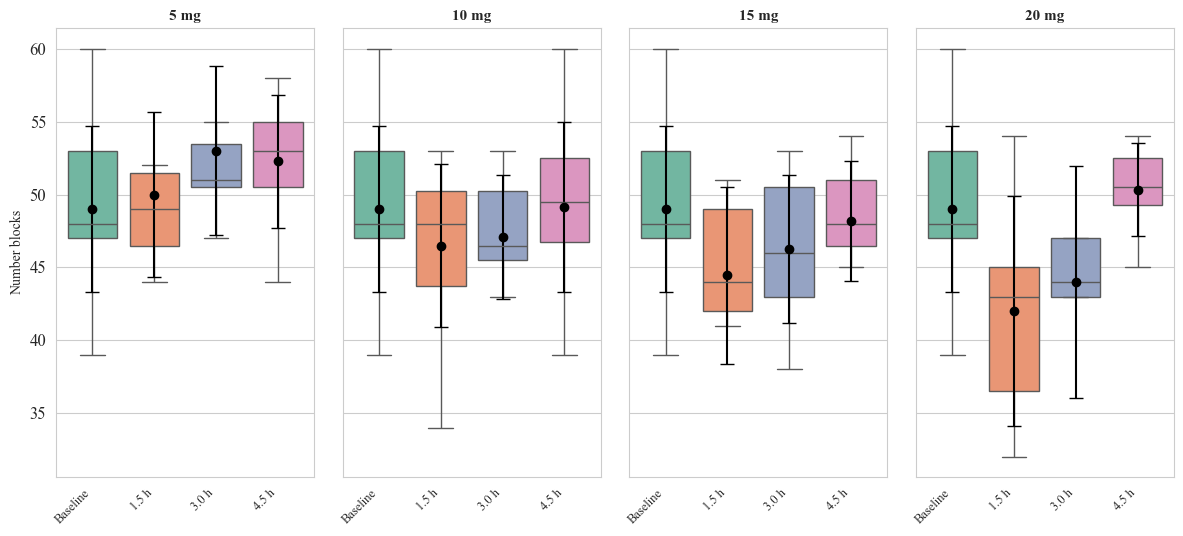

Participants included across doses for Box and Block (modified): []
The following participants had no positive Box and Block (modified) observations and were excluded entirely: ['HC01', 'HC02', 'HC03', 'HC04', 'HC05', 'HC06', 'HC08', 'HC09', 'HC10', 'HC11', 'HC12', 'HC13', 'HC14']

Sessions excluded because target variable was zero or non-positive (per dose):
- Dose 20 mg (Box and Block (modified)):
Subject Timepoint  dose_mg  Box and Block (modified)
   HC08   20mg-3h       20                         0

DATA POINTS PER BOXPLOT FOR: Box and Block (modified)
Dose (mg)    5     10    15    20
Timepoint                        
1.5 h       7.0  12.0  11.0   6.0
3.0 h       7.0  12.0  11.0   5.0
4.5 h       7.0  12.0  11.0   6.0
Baseline   13.0  13.0  13.0  13.0

Total data points for Box and Block (modified): 159



In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare global labels and color map to ensure consistency across plots
# create a simple time label (Baseline or "<hours> h") for the whole df
bb_behavioural_results['time_label'] = bb_behavioural_results.apply(
    lambda r: 'Baseline' if r['Condition'] == 'Baseline' else f"{r['dose_hr']} h", axis=1
)
participant_ids = bb_behavioural_results['Subject'].unique()

# order baseline first, then numeric times sorted
all_time_labels = list(bb_behavioural_results['time_label'].unique())
if 'Baseline' in all_time_labels:
    all_time_labels.remove('Baseline')
    try:
        all_time_labels = ['Baseline'] + sorted(all_time_labels, key=lambda x: float(str(x).split()[0]))
    except Exception:
        all_time_labels = ['Baseline'] + sorted(all_time_labels, key=str)
else:
    try:
        all_time_labels = sorted(all_time_labels, key=lambda x: float(str(x).split()[0]))
    except Exception:
        all_time_labels = sorted(all_time_labels, key=str)

# Create a fixed color mapping using a palette
# distinct colors for each timepoint
unique_colors = sns.color_palette("Set2", len(all_time_labels))
color_map = dict(zip(all_time_labels, unique_colors))

for target_varible in ['Box and Block (standard)', 'Box and Block (modified)']:
    # track participants included for this metric and sessions excluded due to non-positive values
    included_ids = set()
    missing_sessions = []
    # Track data points per boxplot (timepoint x dose)
    boxplot_counts = []

    global_doses = sorted(bb_behavioural_results['dose_mg'].dropna().unique())
    if 0 in global_doses:
        global_doses.remove(0)  # Remove baseline from dose list

    # Boxplots per dose with mean ± SD overlay
    fig, axes = plt.subplots(1, len(global_doses), figsize=(3 * len(global_doses), 6), sharey=True)
    axes = np.atleast_1d(axes)

    # Pre-fetch baseline data to include in every plot
    baseline_data = bb_behavioural_results[bb_behavioural_results['Condition'] == 'Baseline'].copy()

    for ax, dose in zip(axes, global_doses):
        dose_subset = bb_behavioural_results[bb_behavioural_results['dose_mg'] == dose].copy()
        
        # Identify rows that will be excluded (target variable non-positive) in this dose (and baseline)
        temp_combined = pd.concat([baseline_data, dose_subset], ignore_index=True)
        excluded_rows = temp_combined[(temp_combined[target_varible].isna()) | (temp_combined[target_varible] <= 0)][['Subject', 'Timepoint', 'dose_mg', target_varible]].drop_duplicates()
        if not excluded_rows.empty:
            missing_sessions.append({'dose': dose, 'target_varible': target_varible, 'rows': excluded_rows})
        
        # If this dose is different from 0 (baseline), combine with baseline data
        if dose != 0:
            subset = pd.concat([baseline_data, dose_subset], ignore_index=True)
        else:
            continue  # Skip plotting for baseline alone

        # remove 0 results
        subset = subset[subset[target_varible]>0]

        
        
        

        if subset.empty:
            ax.set_title(f'{dose} mg\nNo data', fontsize=10)
            ax.set_xticks([])
            continue

        # Get labels present in this subset, maintaining the global order
        present_labels = [lbl for lbl in all_time_labels if lbl in subset['time_label'].unique()]

        # Count data points per timepoint for this dose
        for lbl in present_labels:
            n_points = len(subset[subset['time_label'] == lbl])
            boxplot_counts.append({
                'Metric': target_varible,
                'Dose (mg)': int(dose),
                'Timepoint': lbl,
                'N_datapoints': n_points
            })

        # Use hue to assign a unique color to each time_label using the fixed color_map
        sns.boxplot(data=subset, x='time_label', y=target_varible, order=present_labels,
                    hue='time_label', palette=color_map, dodge=False,
                    ax=ax, showfliers=False)
        
        # Remove the legend as the x-axis labels are sufficient
        if ax.get_legend():
            ax.get_legend().remove()

        # overlay mean ± SD
        stats = subset.groupby('time_label')[target_varible].agg(['mean', 'std']).reindex(present_labels)
        for i, lbl in enumerate(present_labels):
            mean = stats.loc[lbl, 'mean']
            sd = stats.loc[lbl, 'std']
            ax.errorbar(i, mean, yerr=sd if not np.isnan(sd) else 0, color='k', fmt='o', capsize=5)

        ax.set_title(f'{int(dose)} mg', fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        # Fix: set fixed tick positions before setting tick labels to avoid matplotlib UserWarning
        ax.set_xticks(range(len(present_labels)))
        ax.set_xticklabels(present_labels, rotation=45, ha='right', fontsize=9)

    axes[0].set_ylabel(f'Number blocks', fontsize=10)
    target = "Box and Block" if 'standard' in target_varible else "Box and Block (modified)"
    #plt.suptitle(f'{target} — Average Performance ± SD', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f'plots/{target_varible.replace(" ", "_").lower()}_boxplots_mean_sd.png', dpi=300)
    plt.show()

    # Summary across doses for this metric
    print(f"Participants included across doses for {target_varible}: {sorted(included_ids)}")

    missing_participants = set(participant_ids) - included_ids
    if missing_participants:
        print(f"The following participants had no positive {target_varible} observations and were excluded entirely: {sorted(missing_participants)}")

    if missing_sessions:
        print("\nSessions excluded because target variable was zero or non-positive (per dose):")
        for ms in missing_sessions:
            print(f"- Dose {ms['dose']} mg ({ms['target_varible']}):")
            print(ms['rows'].to_string(index=False))
    
    # Print data points per boxplot
    print(f"\n{'='*60}")
    print(f"DATA POINTS PER BOXPLOT FOR: {target_varible}")
    print(f"{'='*60}")
    if boxplot_counts:
        counts_df = pd.DataFrame(boxplot_counts)
        # Pivot to show in a nice table format
        pivot_counts = counts_df.pivot_table(
            index='Timepoint', 
            columns='Dose (mg)', 
            values='N_datapoints', 
            fill_value=0
        )
        print(pivot_counts)
        print(f"\nTotal data points for {target_varible}: {counts_df['N_datapoints'].sum()}")
    else:
        print("No data points to display.")
    print(f"{'='*60}\n")


### Individual doese effects

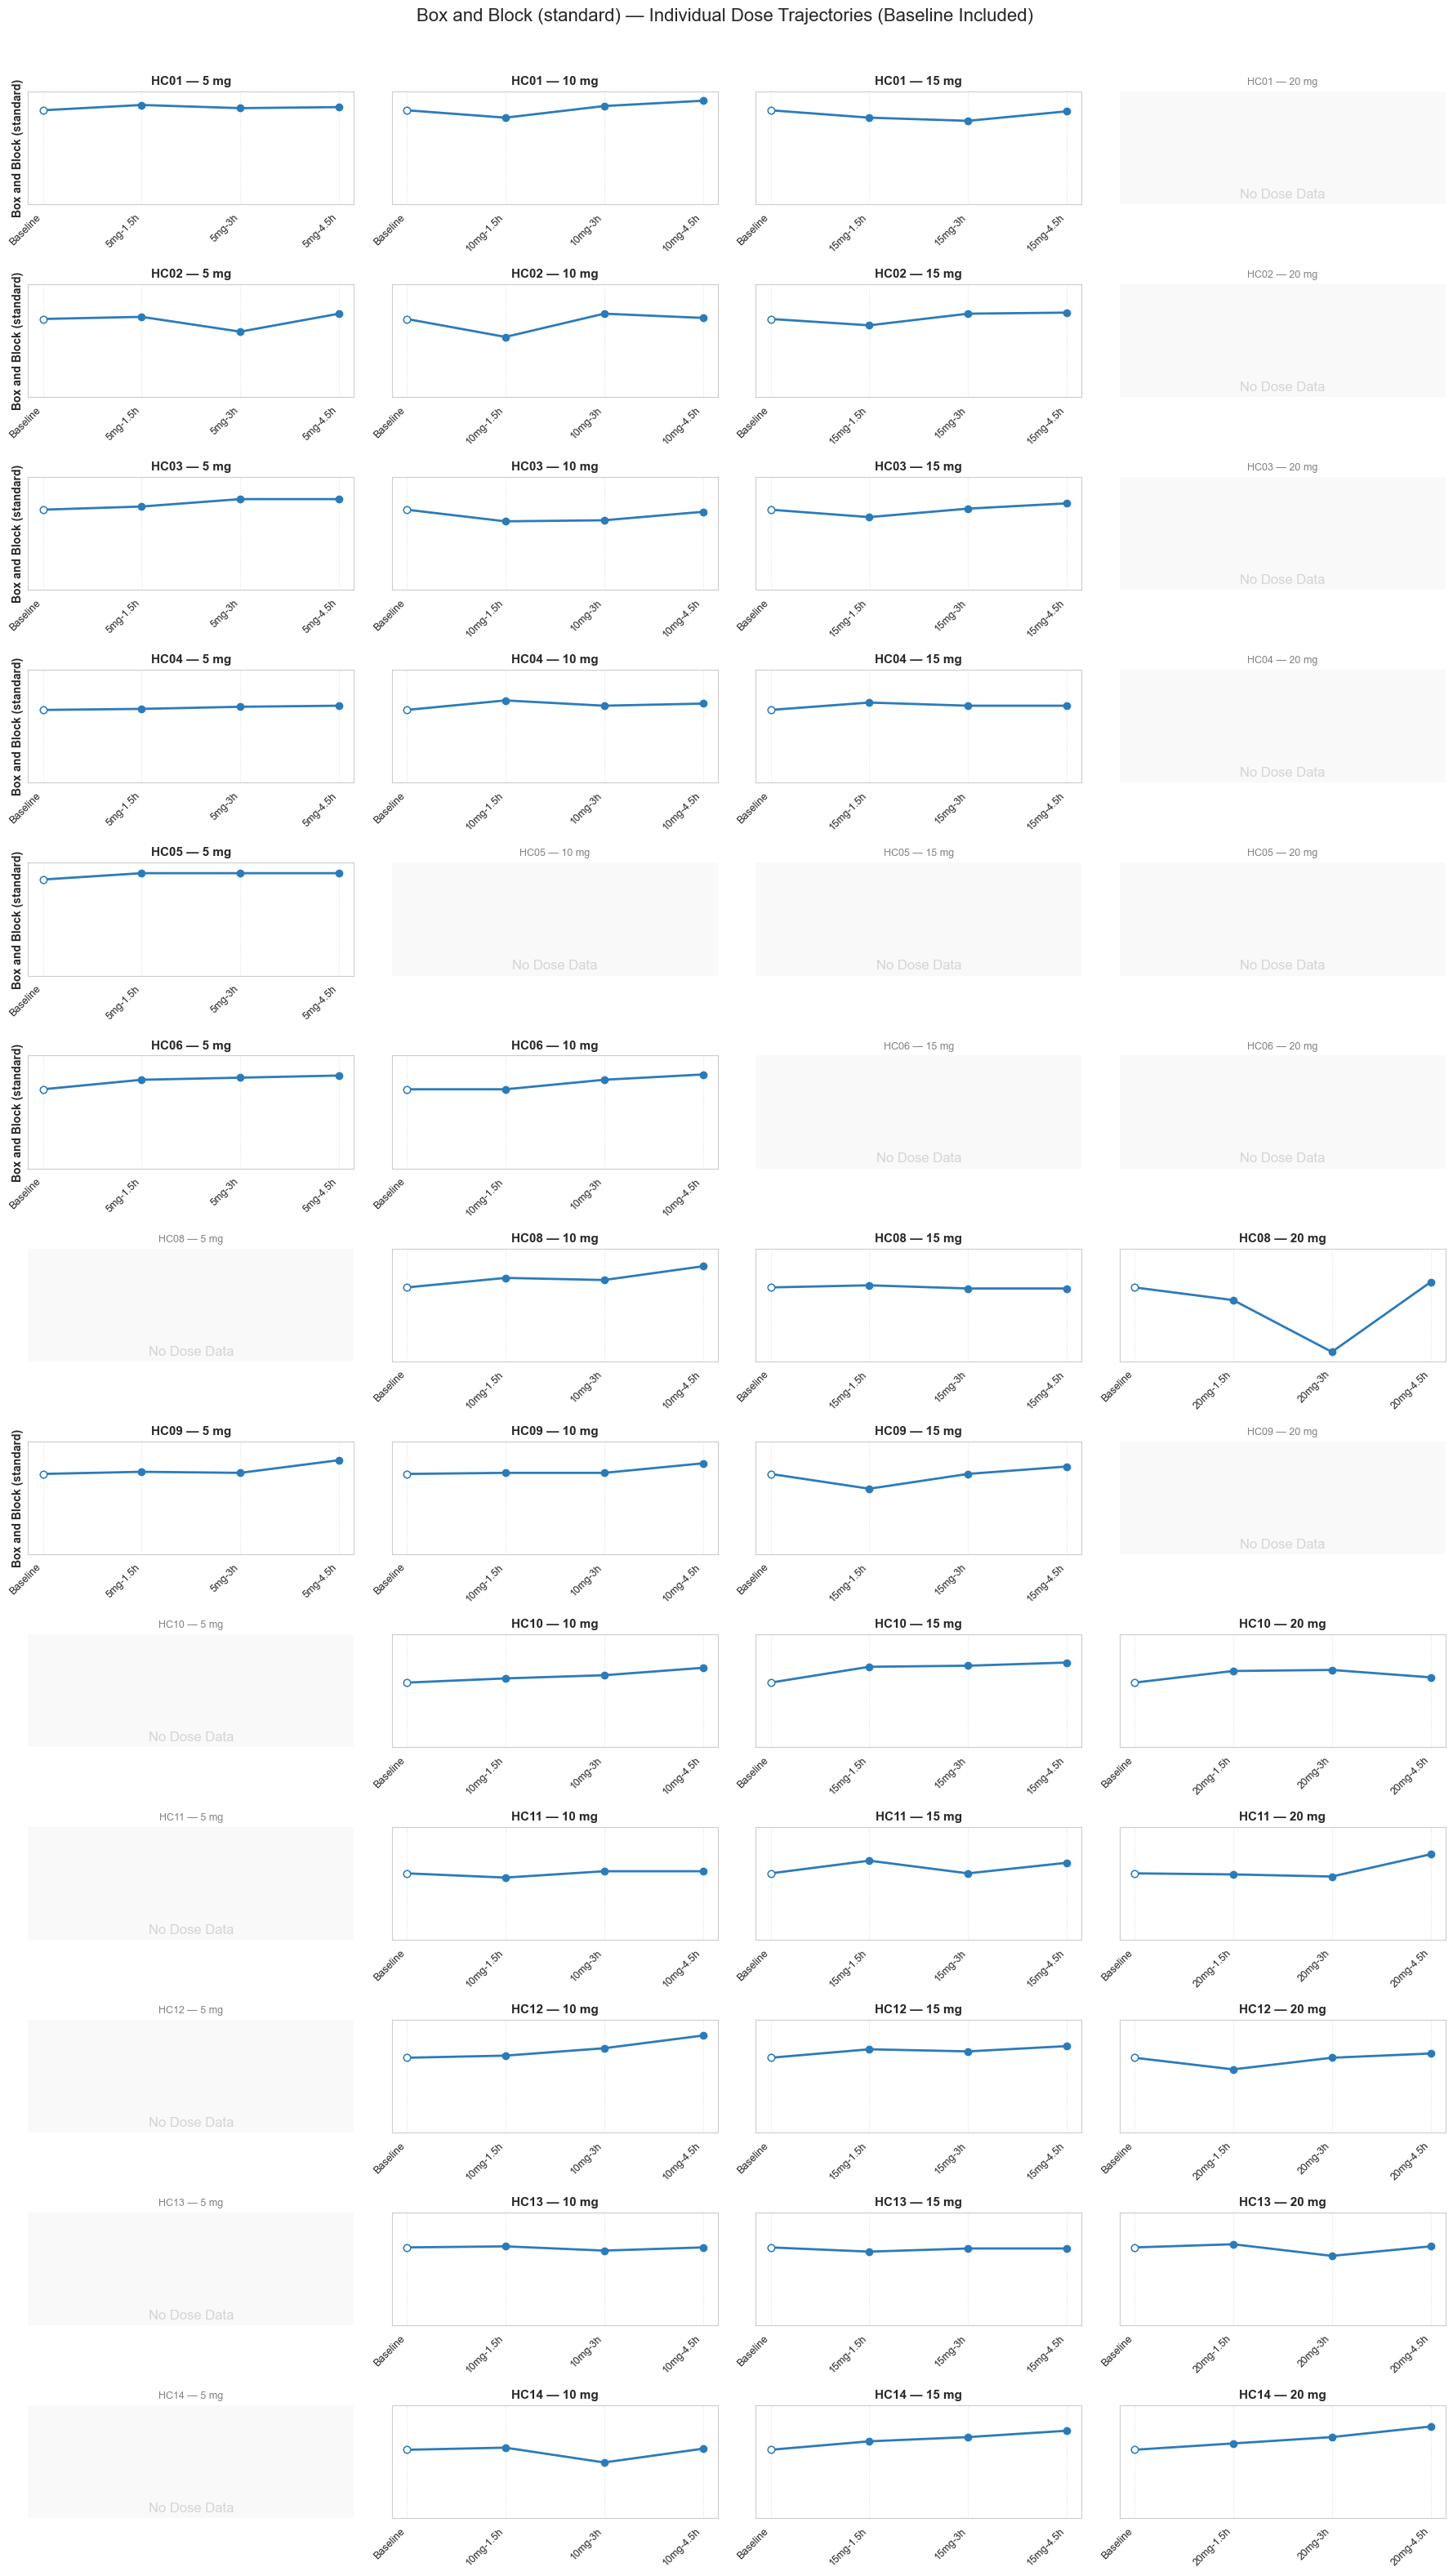

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# ==========================================
# 1. CONFIGURATION (CRITICAL)
# ==========================================
metric_col = 'Box and Block (standard)'  # Change this to the metric you want to plot

# CHECK THIS: What is the exact string in your 'Timepoint' column for baseline?
BASELINE_LABEL = 'Baseline' 

# Define Time Order to ensure Baseline is always first on the X-axis
# Add the rest of your timepoints in chronological order
time_order = [BASELINE_LABEL, '10 mins', '20 mins', '30 mins', '40 mins'] 

# If you don't know the other timepoints, we can auto-fill the rest:
existing_times = bb_behavioural_results['Timepoint'].astype(str).unique()
remaining_times = sorted([t for t in existing_times if t != BASELINE_LABEL])
full_time_order = [BASELINE_LABEL] + remaining_times

# Apply Sorting Order to DataFrame
bb_behavioural_results['Timepoint'] = pd.Categorical(
    bb_behavioural_results['Timepoint'], 
    categories=full_time_order, 
    ordered=True
)

# ==========================================
# 2. SETUP DOSES & AXES
# ==========================================
participants = sorted(bb_behavioural_results['Subject'].unique())

# Get global doses, but EXCLUDE 0 or NaN if they represent baseline/placebo
# (assuming you only want columns for the dose Doses)
all_doses = sorted(bb_behavioural_results['dose_mg'].dropna().unique())
# Filter out 0 if it exists, assuming 0 is baseline
global_doses = [d for d in all_doses if d != 0] 

n_rows = len(participants)
n_cols = len(global_doses)

# Global Y-Limits
all_vals = bb_behavioural_results[metric_col].dropna()
if not all_vals.empty:
    y_min, y_max = all_vals.min(), all_vals.max()
    y_pad = (y_max - y_min) * 0.1
    y_limits = (y_min - y_pad, y_max + y_pad)
else:
    y_limits = (0, 100)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols + 2, 2.5 * n_rows), sharex=False, sharey=True)
axes = np.atleast_2d(axes)

# ==========================================
# 3. PLOTTING LOOP
# ==========================================
for r, participant in enumerate(participants):
    # Get all data for this participant
    p_data = bb_behavioural_results[bb_behavioural_results['Subject'] == participant]
    
    # 1. Extract the Baseline Row(s) specifically
    # We look for the Timepoint, regardless of what 'dose_mg' says for that row
    baseline_data = p_data[p_data['Timepoint'] == BASELINE_LABEL]

    for c, target_dose in enumerate(global_doses):
        ax = axes[r, c]
        
        # 2. Extract the dose Dose Data (excluding baseline timepoint to avoid dupes)
        dose_data = p_data[
            (p_data['dose_mg'] == target_dose) & 
            (p_data['Timepoint'] != BASELINE_LABEL)
        ]
        
        # 3. Combine Baseline + dose
        plot_data = pd.concat([baseline_data, dose_data])
        
        # Check if we have enough data to plot (must have at least the dose dose)
        if dose_data.empty:
            ax.set_facecolor('#f9f9f9')
            for spine in ax.spines.values(): spine.set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.text(0.5, 0.5, 'No Dose Data', ha='center', va='center', color='gray', alpha=0.3)
            ax.set_title(f'{participant} — {target_dose} mg', color='gray', fontsize=9)
        else:
            # Sort by the categorical time order defined at the top
            plot_data = plot_data.sort_values('Timepoint')
            
            x = np.arange(len(plot_data))
            labels = plot_data['Timepoint'].tolist()
            y = plot_data[metric_col].values

            # Plot
            ax.plot(x, y, 'o-', color='#2b7bba', markersize=6, linewidth=2)
            
            # Formatting
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
            ax.set_ylim(y_limits)
            ax.grid(True, linestyle=':', alpha=0.6)
            
            # Highlight Baseline point visually (optional)
            if not baseline_data.empty:
                # Assuming baseline is always index 0 after sorting
                ax.plot(x[0], y[0], 'o', color='white', markeredgecolor='#2b7bba', markersize=6)

            if c == 0:
                ax.set_ylabel(metric_col, fontsize=10, fontweight='bold')
            
            ax.set_title(f'{participant} — {target_dose} mg', fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.suptitle(f'{metric_col} — Individual Dose Trajectories (Baseline Included)', fontsize=16, y=1.0)
plt.show()



### Investigating learning effects

In [10]:
import warnings
from IPython.display import display
from statsmodels.formula.api import ols, mixedlm
from statsmodels.tools.sm_exceptions import ConvergenceWarning

analysis_metrics = [
    'Box and Block (standard)',
    'Box and Block (modified)'
]

learning_tables = {}
adjusted_tables = {}
residual_summaries = {}
mixedlm_results = {}
mixedlm_coefs = {}
group_predictions = {}



for metric in analysis_metrics:
    metric_cols = ['Subject', 'Timepoint', 'dose_mg', 'dose_hr', 'Condition', metric]
    metric_df = bb_behavioural_results[metric_cols].dropna(subset=[metric]).copy()
    #also remove 0 values
    metric_df = metric_df[metric_df[metric] > 0]
     # Remove non-positive scores if applicable
    if metric_df.empty:
        continue

    metric_df = metric_df.sort_values(['Subject', 'dose_mg', 'dose_hr']).reset_index(drop=True)
    metric_df['session_index'] = metric_df.groupby('Subject').cumcount()
    metric_df.rename(columns={metric: 'metric_value'}, inplace=True)

    slopes, adjusted_records = [], []
    for subject_id, sub_df in metric_df.groupby('Subject'):
        sub_df = sub_df.copy()
        if sub_df['metric_value'].nunique() < 2 or len(sub_df) < 2:
            sub_df['learning_adjusted'] = np.nan
            slopes.append({
                'Subject': subject_id,
                'n_sessions': len(sub_df),
                'learning_slope': np.nan,
                'learning_pvalue': np.nan,
                'baseline_score': sub_df.loc[sub_df['session_index'] == 0, 'metric_value'].iloc[0],
                'last_score': sub_df.loc[sub_df['session_index'].idxmax(), 'metric_value']
            })
            adjusted_records.append(sub_df[['Subject', 'Timepoint', 'dose_mg', 'session_index', 'metric_value', 'learning_adjusted']])
            continue

        lm_model = ols('metric_value ~ session_index', data=sub_df).fit()
        sub_df['learning_adjusted'] = lm_model.resid

        slopes.append({
            'Subject': subject_id,
            'n_sessions': len(sub_df),
            'learning_slope': lm_model.params.get('session_index', np.nan),
            'learning_pvalue': lm_model.pvalues.get('session_index', np.nan),
            'baseline_score': sub_df.loc[sub_df['session_index'] == 0, 'metric_value'].iloc[0],
            'last_score': sub_df.loc[sub_df['session_index'].idxmax(), 'metric_value'],
            'diff_score': sub_df.loc[sub_df['session_index'].idxmax(), 'metric_value'] - sub_df.loc[sub_df['session_index'] == 0, 'metric_value'].iloc[0]
        })
        adjusted_records.append(sub_df[['Subject', 'Timepoint', 'dose_mg', 'session_index', 'metric_value', 'learning_adjusted']])

    slopes_df = pd.DataFrame(slopes)
    learning_tables[metric] = slopes_df
    adjusted_df = pd.concat(adjusted_records, ignore_index=True)
    adjusted_tables[metric] = adjusted_df
    residual_summaries[metric] = adjusted_df.groupby('dose_mg')['learning_adjusted'].agg(['mean', 'std', 'count']).dropna(how='all')

    metric_df['dose_mg'] = metric_df['dose_mg'].fillna(0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        try:
            mixed_model = mixedlm('metric_value ~ session_index + C(dose_mg)', data=metric_df, groups=metric_df['Subject'])
            mixed_result = mixed_model.fit(method='lbfgs', maxiter=200)
        except Exception:
            mixed_result = None

    mixedlm_results[metric] = mixed_result
    if mixed_result is not None:
        coef_df = pd.DataFrame({
            'coef': mixed_result.params,
            'std_err': mixed_result.bse,
            'z_value': mixed_result.tvalues,
            'p_value': mixed_result.pvalues
        })
        mixedlm_coefs[metric] = coef_df

        mean_session = metric_df['session_index'].mean()
        pred_rows = []
        for dose in sorted(metric_df['dose_mg'].unique()):
            pred = mixed_result.params.get('Intercept', 0.0)
            pred += mixed_result.params.get('session_index', 0.0) * mean_session
            if dose != 0:
                pred += mixed_result.params.get(f'C(dose_mg)[T.{dose}]', 0.0)
            pred_rows.append({'dose_mg': dose, 'predicted_metric': pred})
        group_predictions[metric] = pd.DataFrame(pred_rows)
    else:
        mixedlm_coefs[metric] = None
        group_predictions[metric] = None

primary_metric = 'Box and Block (standard)'
print('Learning slopes (per participant) for primary metric:')
if primary_metric in learning_tables:
    display(learning_tables[primary_metric])

print('\nDose-adjusted residual summary for primary metric:')
if primary_metric in residual_summaries:
    display(residual_summaries[primary_metric])

print('\nMixed-effects dose effects (controlling for session index):')
if primary_metric in mixedlm_coefs and mixedlm_coefs[primary_metric] is not None:
    display(mixedlm_coefs[primary_metric])
else:
    print('Mixed model did not converge for the primary metric.')

Learning slopes (per participant) for primary metric:


/Users/pierre/Desktop/MelbourneProject/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/pierre/Desktop/MelbourneProject/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


,Subject,n_sessions,learning_slope,learning_pvalue,baseline_score,last_score,diff_score
0,HC01,10,-0.787879,0.262817,80,79,-1
1,HC02,10,0.696970,0.460240,65,71,6
2,HC03,10,-0.484848,0.592952,67,73,6
3,HC04,10,0.472727,0.108366,60,64,4
4,HC05,4,1.800000,0.225403,82,88,6
5,HC06,7,1.107143,0.355495,66,80,14
6,HC08,9,-1.333333,0.263363,61,66,5
7,HC09,10,-0.212121,0.808500,67,74,7
8,HC10,10,0.830303,0.234487,52,57,5
9,HC11,10,1.006061,0.226357,54,72,18



Dose-adjusted residual summary for primary metric:


,mean,std,count
dose_mg,,,
0,-2.321506,4.113698,13
5,2.321800,4.500823,21
10,-0.060618,6.788017,36
15,0.834894,5.335755,33
20,-2.585146,6.905110,17



Mixed-effects dose effects (controlling for session index):


,coef,std_err,z_value,p_value
Intercept,64.384615,2.392625,26.909619,1.694824e-159
C(dose_mg)[T.5],4.985120,2.478221,2.011572,4.426508e-02
C(dose_mg)[T.10],-5.716976,3.022297,-1.891600,5.854430e-02
C(dose_mg)[T.15],-11.622252,4.483015,-2.592508,9.527898e-03
C(dose_mg)[T.20],-20.416043,6.011764,-3.396015,6.837450e-04
session_index,2.336014,0.604494,3.864414,1.113561e-04
Group Var,0.741961,0.393966,1.883310,5.965838e-02


#### Plot participants with learning tendency (HC06 , HC11 and HC14)

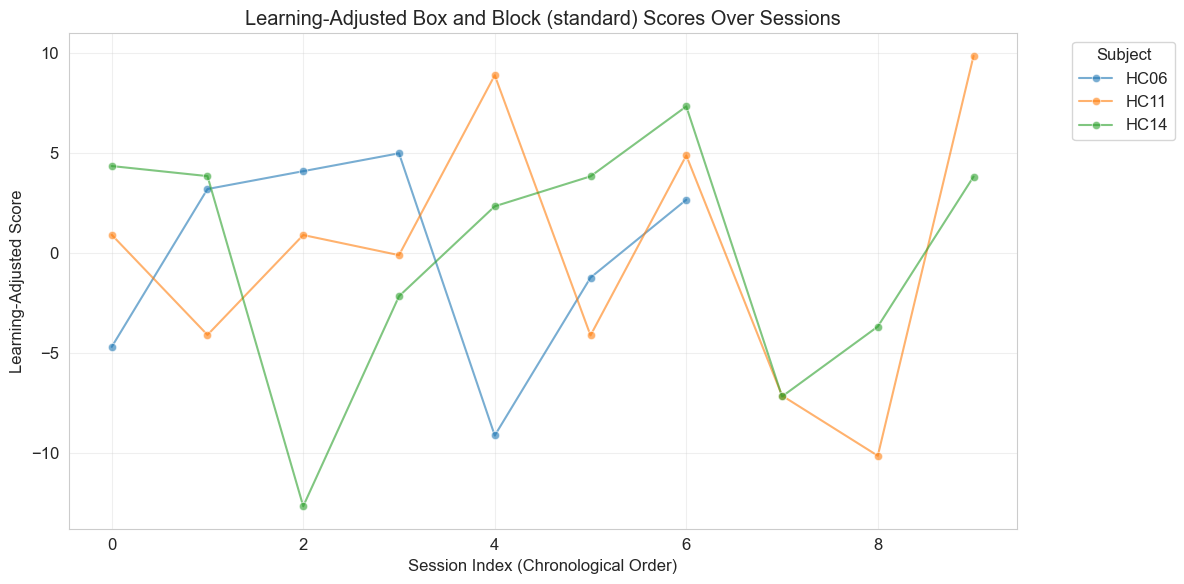

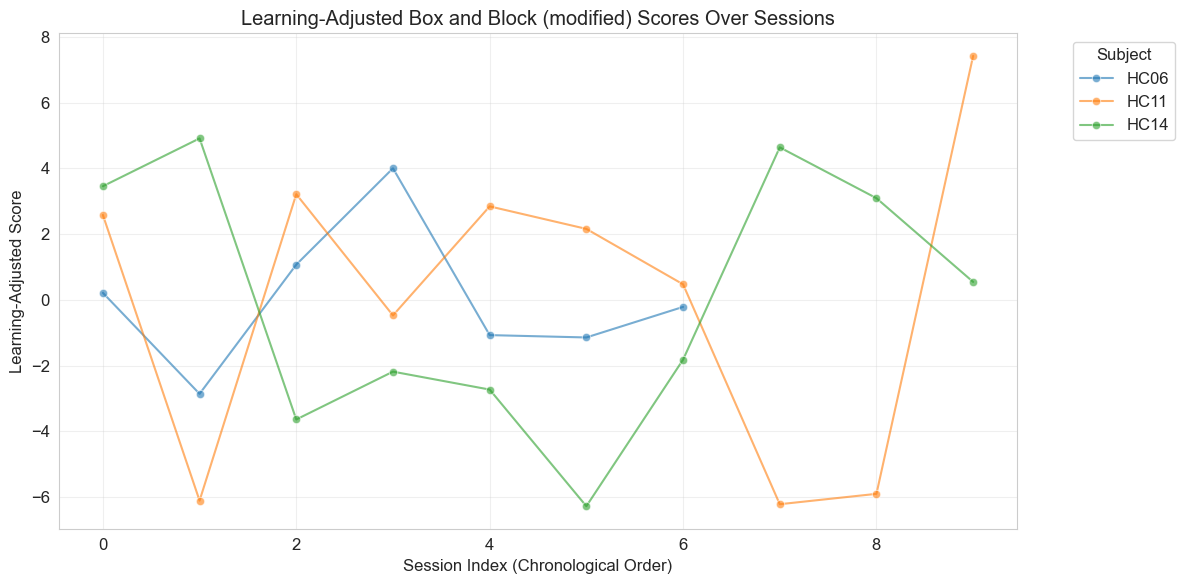

In [11]:
participant_to_plot = ['HC06', 'HC11', 'HC14']
#plot sessions in chronical order
for metric in analysis_metrics:
    if metric not in adjusted_tables:
        continue

    adj_df = adjusted_tables[metric]
    adj_df = adj_df[adj_df['Subject'].isin(participant_to_plot)]
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=adj_df, x='session_index', y='learning_adjusted', hue='Subject', marker='o', alpha=0.6)
    plt.title(f'Learning-Adjusted {metric} Scores Over Sessions')
    plt.xlabel('Session Index (Chronological Order)')
    plt.ylabel('Learning-Adjusted Score')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Subject')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Learning controlled dose effects

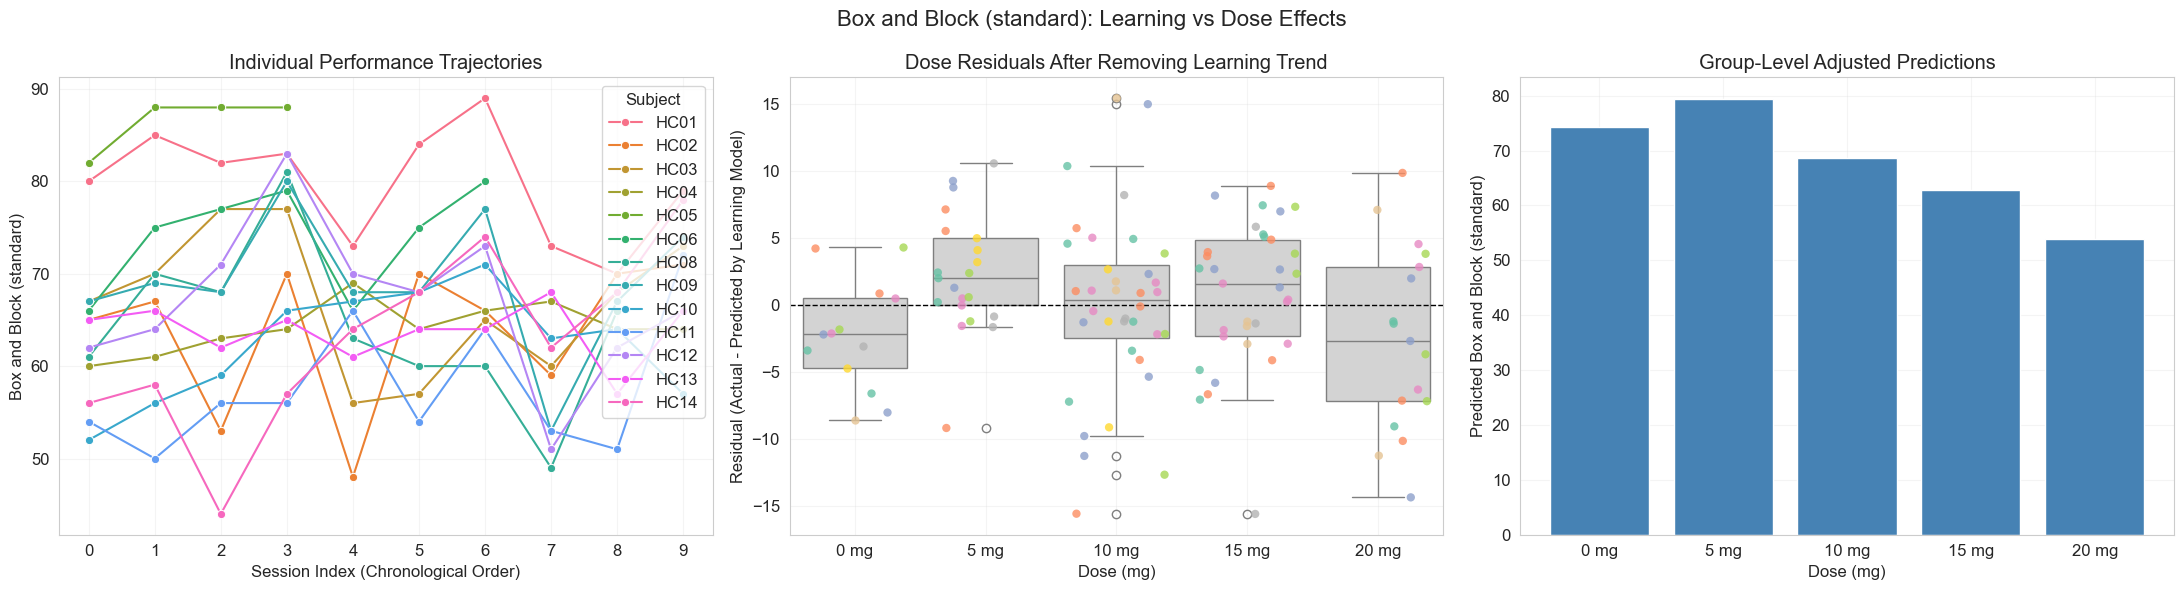

In [12]:
primary_metric = 'Box and Block (standard)'
if primary_metric in adjusted_tables:
    plot_df = adjusted_tables[primary_metric].copy()
    if not plot_df.empty:
        plot_df['dose_mg'] = plot_df['dose_mg'].fillna(0)
        plot_df['dose_label'] = plot_df['dose_mg'].astype(int).astype(str) + ' mg'

        unique_sessions = sorted(plot_df['session_index'].unique())

        fig, axes = plt.subplots(1, 3, figsize=(22, 6))

        sns.lineplot(
            data=plot_df,
            x='session_index',
            y='metric_value',
            hue='Subject',
            marker='o',
            ax=axes[0]
        )
        axes[0].set_title('Individual Performance Trajectories')
        axes[0].set_xlabel('Session Index (Chronological Order)')
        axes[0].set_ylabel(primary_metric)
        axes[0].set_xticks(unique_sessions)
        axes[0].grid(alpha=0.2)

        sns.boxplot(
            data=plot_df,
            x='dose_label',
            y='learning_adjusted',
            order=sorted(plot_df['dose_label'].unique(), key=lambda x: int(x.split()[0])),
            ax=axes[1],
            color='lightgray'
        )
        sns.stripplot(
            data=plot_df,
            x='dose_label',
            y='learning_adjusted',
            order=sorted(plot_df['dose_label'].unique(), key=lambda x: int(x.split()[0])),
            hue='Subject',
            dodge=True,
            ax=axes[1],
            palette='Set2',
            size=6,
            alpha=0.8
        )
        axes[1].axhline(0, color='k', linestyle='--', linewidth=1)
        axes[1].set_title('Dose Residuals After Removing Learning Trend')
        axes[1].set_xlabel('Dose (mg)')
        axes[1].set_ylabel('Residual (Actual - Predicted by Learning Model)')
        axes[1].grid(alpha=0.2)
        axes[1].legend_.remove()

        pred_df = group_predictions.get(primary_metric)
        if pred_df is not None and not pred_df.empty:
            pred_df = pred_df.sort_values('dose_mg')
            axes[2].bar(pred_df['dose_mg'].astype(int).astype(str) + ' mg', pred_df['predicted_metric'], color='steelblue')
            axes[2].set_title('Group-Level Adjusted Predictions')
            axes[2].set_xlabel('Dose (mg)')
            axes[2].set_ylabel(f'Predicted {primary_metric}')
            axes[2].grid(alpha=0.2)
        else:
            axes[2].set_visible(False)

        plt.suptitle(f'{primary_metric}: Learning vs Dose Effects', fontsize=16)
        plt.tight_layout()
        plt.show()
else:
    print('No adjusted data available for the primary metric.')

### Mixed effect linear Bayesian model

#### Box and block standard 

In [13]:
# import pymc as pm
# import arviz as az

# bayes_metric = 'Box and Block (standard)'

# bayes_cols = ['Subject', 'Timepoint', 'dose_mg', 'dose_hr', 'Condition', bayes_metric]
# bayes_df = bb_behavioural_results[bayes_cols].dropna(subset=[bayes_metric]).copy()
# if bayes_df.empty:
#     raise ValueError(f'No data available for {bayes_metric}.')

# bayes_df = bayes_df[bayes_df[bayes_metric] > 0].copy()
# if bayes_df.empty:
#     raise ValueError('All observations were zero; nothing to model.')

# bayes_df = bayes_df.sort_values(['Subject', 'dose_mg', 'dose_hr']).reset_index(drop=True)
# bayes_df['session_index'] = bayes_df.groupby('Subject').cumcount()

# subject_cat = pd.Categorical(bayes_df['Subject'])
# subject_idx = subject_cat.codes
# dose_series = bayes_df['dose_mg'].fillna(0).astype(int)
# dose_levels = sorted(dose_series.unique())
# nonzero_doses = [d for d in dose_levels if d != 0]

# dose_design = pd.get_dummies(dose_series).reindex(columns=nonzero_doses, fill_value=0).to_numpy(dtype=float)
# metric_values = bayes_df[bayes_metric].to_numpy(dtype=float)
# session_vals = bayes_df['session_index'].to_numpy(dtype=float)

# timepoint_cat = pd.Categorical(bayes_df['Timepoint'])
# timepoint_idx = timepoint_cat.codes
# coords = {
#     'subject': subject_cat.categories,
#     'cell': timepoint_cat.categories
# }

# with pm.Model(coords=coords) as bayes_model:
#     # --- Data ---
#     sub_idx = pm.Data('sub_idx', subject_idx)
#     tp_idx = pm.Data('tp_idx', timepoint_idx)
#     session = pm.Data('session', session_vals)

#     # --- Random Intercept (Baseline) ---
#     mu_group = pm.LogNormal('mu_group', mu=np.log(30), sigma=np.log(10)) 
#     sigma_subject = pm.HalfNormal('sigma_subject', 5.0)
#     subject_offset = pm.Normal('subject_offset', 0, 1, dims='subject')
    
#     # --- Random Slopes (The Isolated Dose-Time Effects) ---
#     # Global average for each unique Dose_Hour cell
#     mu_beta_cell = pm.Normal('mu_beta_cell', 0, 2, dims='cell')
#     # Variability between subjects in how they react to that specific cell
#     sigma_beta_dose = pm.HalfNormal('sigma_beta_cell', 1, dims='cell')
#     # Individual deviations
#     cell_offset = pm.Normal('cell_offset', 0, 1, dims=('subject', 'cell'))
    
#     # The actual effect for Subject S at Timepoint T
#     # Resulting shape: (n_subjects, n_cells)
#     beta_cell_subject = mu_beta_cell + sigma_beta_cell * cell_offset

#     # --- Fixed Effect (Practice/Learning) ---
#     beta_session = pm.Normal('beta_session', 0, 2)

#     # --- Linear Equation ---
#     # We use indexing to pull the specific subject and the specific dose_time cell
#     mu = (
#         mu_group + (sigma_subject * subject_offset[sub_idx]) + # Baseline
#         beta_session * session +                              # Practice
#         beta_cell_subject[sub_idx, tp_idx]                    # ISOLATED effect
#     )

#     sigma = pm.HalfNormal('sigma', 5.0)
#     pm.Normal('obs', mu=mu, sigma=sigma, observed=metric_values)
    
#     trace = pm.sample(2000, tune=2000, target_accept=0.95)

# # --- Summary and Plotting ---
#     az_summary = az.summary(
#     trace, 
#     var_names=['mu_group', 'beta_session', 'mu_beta_cell', 'sigma_subject', 'sigma_beta_cell']
# )
# display(az_summary)

# # Visualise the variability in dose response
# az.plot_forest(trace, var_names=['mu_beta_cell', 'sigma_beta_cell'], combined=True)
# plt.title("Global Dose Effects & Inter-Subject Variability")
# plt.show()

Initializing NUTS using jitter+adapt_diag...


Baseline Reference: Baseline
dose Conditions: ['10mg-1.5h', '10mg-3h', '10mg-4.5h', '15mg-1.5h', '15mg-3h', '15mg-4.5h', '20mg-1.5h', '20mg-3h', '20mg-4.5h', '5mg-1.5h', '5mg-3h', '5mg-4.5h']


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_baseline, sigma_subject, subject_offset, mu_beta_dose, sigma_beta_dose, dose_offset, beta_session, sigma]


Output()

/Users/pierre/Desktop/MelbourneProject/.venv/lib/python3.13/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 18 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_baseline,66.607,2.295,62.368,71.009,0.047,0.026,2402.0,4022.0,1.0
beta_session,0.172,0.246,-0.310,0.607,0.002,0.003,12505.0,6387.0,1.0
mu_beta_dose[10mg-1.5h],-2.080,1.429,-4.927,0.528,0.012,0.017,14081.0,6128.0,1.0
mu_beta_dose[10mg-3h],-0.661,1.436,-3.376,1.982,0.011,0.018,17970.0,6169.0,1.0
mu_beta_dose[10mg-4.5h],2.473,1.450,-0.168,5.288,0.012,0.017,15796.0,6336.0,1.0
mu_beta_dose[15mg-1.5h],-0.943,1.467,-3.559,1.886,0.012,0.017,15859.0,5901.0,1.0
mu_beta_dose[15mg-3h],-0.222,1.507,-3.025,2.631,0.011,0.019,17734.0,5760.0,1.0
mu_beta_dose[15mg-4.5h],1.825,1.535,-1.097,4.622,0.012,0.017,15445.0,6021.0,1.0
mu_beta_dose[20mg-1.5h],-2.274,1.727,-5.570,0.914,0.013,0.023,17624.0,6058.0,1.0
mu_beta_dose[20mg-3h],-1.137,1.703,-4.371,2.101,0.014,0.023,15149.0,5339.0,1.0


<Figure size 1000x600 with 0 Axes>

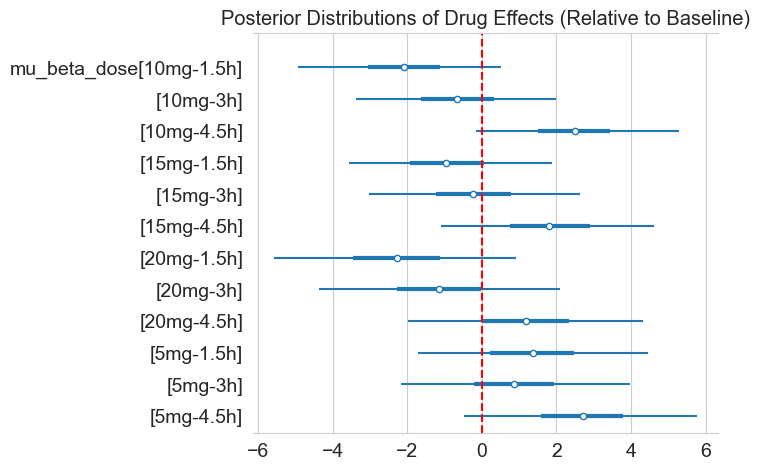

In [14]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Data Setup ---
bayes_metric = 'Box and Block (standard)'
# Assuming bb_behavioural_results is already loaded
bayes_cols = ['Subject', 'Timepoint', 'dose_mg', 'dose_hr', 'Condition', bayes_metric]
bayes_df = bb_behavioural_results[bayes_cols].dropna(subset=[bayes_metric]).copy()

if bayes_df.empty:
    raise ValueError(f'No data available for {bayes_metric}.')

#Exclude 0 or negative values
bayes_df = bayes_df[bayes_df[bayes_metric] > 0].copy()
bayes_df = bayes_df.sort_values(['Subject', 'dose_mg', 'dose_hr']).reset_index(drop=True)
bayes_df['session_index'] = bayes_df.groupby('Subject').cumcount()

# --- 2. Identify Baseline vs. dose Cells ---
# We assume the 'Baseline' row is identified by dose_mg == 0.
# If your column 'Timepoint' explicitly says 'Baseline', use that.
# Here we ensure we know exactly which string refers to the baseline.
baseline_mask = bayes_df['dose_mg'] == 0
baseline_label = bayes_df.loc[baseline_mask, 'Timepoint'].unique()[0]

# Get all unique timepoints
all_timepoints = sorted(bayes_df['Timepoint'].unique())
# Filter to keep only the "dose" (Drug) conditions
dose_cells = [t for t in all_timepoints if t != baseline_label]

print(f"Baseline Reference: {baseline_label}")
print(f"dose Conditions: {dose_cells}")

# --- 3. Create "dose" Design Matrix ---
# This matrix has 1s for dose doses and 0s for Baseline
# Shape: (n_observations, n_dose_cells)
dose_design = pd.get_dummies(bayes_df['Timepoint'])[dose_cells].to_numpy(dtype=float)

# --- 4. Coordinates & Indices ---
subject_cat = pd.Categorical(bayes_df['Subject'])
subject_idx = subject_cat.codes

metric_values = bayes_df[bayes_metric].to_numpy(dtype=float)
session_vals = bayes_df['session_index'].to_numpy(dtype=float)

coords = {
    'subject': subject_cat.categories,
    'dose_cell': dose_cells # Note: 'Baseline' is NOT in here
}

# --- 5. The Model (Reference Coding) ---
with pm.Model(coords=coords) as bayes_model:
    # --- Data Containers ---
    sub_idx = pm.Data('sub_idx', subject_idx)
    session = pm.Data('session', session_vals)
    # The design matrix for doses 
    design_data = pm.Data('dose_design', dose_design)

    # --- Random Intercept (Baseline Score) ---
    mu_baseline = pm.LogNormal('mu_baseline', mu=np.log(30), sigma=np.log(10)) 
    
    # Subject variation on the baseline
    sigma_subject = pm.HalfNormal('sigma_subject', 5.0)
    subject_offset = pm.Normal('subject_offset', 0, 1, dims='subject')
    
    # Calculate Subject-Specific Baseline
    subj_baseline = mu_baseline + sigma_subject * subject_offset[sub_idx]

   
    
    # Global average change for each dose cell
    mu_beta_dose = pm.Normal('mu_beta_dose', 0, 2, dims='dose_cell')
    
    # Variability in response (Heterogeneity)
    sigma_beta_dose = pm.HalfNormal('sigma_beta_dose', 1, dims='dose_cell')
    
    # Individual Subject Deviations for dose cells
    dose_offset = pm.Normal('dose_offset', 0, 1, dims=('subject', 'dose_cell'))
    
    # Reconstruct the matrix of effects: Shape (n_subjects, n_dose_cells)
    beta_dose_subj = mu_beta_dose + sigma_beta_dose * dose_offset

    # --- Fixed Effect (Practice) ---
    beta_session = pm.Normal('beta_session', 0, 2)

    # --- Treatment Effect Calculation ---
    # 1. Select the betas for the current subjects: beta_dose_subj[sub_idx] -> (n_obs, n_dose)
    # 2. Multiply by design matrix (1s and 0s): design_data -> (n_obs, n_dose)
    # 3. Sum across columns to get the single scalar effect for that row
    #    - If row is Baseline, design is all 0s -> treatment_effect = 0
    #    - If row is 5mg, design has a 1 in 5mg col -> treatment_effect = beta_5mg
    treatment_effect = pm.math.sum(design_data * beta_dose_subj[sub_idx], axis=1)

    # --- Linear Predictor ---
    mu = (
        subj_baseline +           # The Subject's starting point
        beta_session * session +  # Their practice gain
        treatment_effect          # The drug effect (0 if baseline)
    )

    sigma = pm.HalfNormal('sigma', 5.0)
    pm.Normal('obs', mu=mu, sigma=sigma, observed=metric_values)
    
    trace = pm.sample(2000, tune=2000, target_accept=0.95, chains=4, random_seed=42)

# --- Summary ---
# Now mu_beta_dose directly shows the "Difference from Baseline"
az_summary = az.summary(
    trace, 
    var_names=['mu_baseline', 'beta_session', 'mu_beta_dose', 'sigma_subject', 'sigma_beta_dose']
)
display(az_summary)

# Forest plot of the EFFECTS (Difference from Baseline)
plt.figure(figsize=(10, 6))
az.plot_forest(trace, var_names=['mu_beta_dose'], combined=True)
plt.title("Posterior Distributions of Drug Effects (Relative to Baseline)")
plt.axvline(0, color='red', linestyle='--') # Zero line is now meaningful
plt.show()

In [15]:
trace.posterior

<xarray.Dataset> Size: 13MB
Dimensions:          (chain: 4, draw: 2000, subject: 13, dose_cell: 12)
Coordinates:
  * chain            (chain) int64 32B 0 1 2 3
  * draw             (draw) int64 16kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
  * subject          (subject) <U4 208B 'HC01' 'HC02' 'HC03' ... 'HC13' 'HC14'
  * dose_cell        (dose_cell) <U9 432B '10mg-1.5h' '10mg-3h' ... '5mg-4.5h'
Data variables:
    subject_offset   (chain, draw, subject) float64 832kB 1.008 ... -1.094
    mu_beta_dose     (chain, draw, dose_cell) float64 768kB -0.9681 ... 1.271
    dose_offset      (chain, draw, subject, dose_cell) float64 10MB 0.4115 .....
    beta_session     (chain, draw) float64 64kB -0.02241 0.2135 ... 0.5222
    mu_baseline      (chain, draw) float64 64kB 67.85 66.71 67.09 ... 70.2 66.52
    sigma_subject    (chain, draw) float64 64kB 7.414 7.151 ... 4.893 5.362
    sigma_beta_dose  (chain, draw, dose_cell) float64 768kB 0.1112 ... 0.3339
    sigma            (chain, draw) float64 64kB 6.352 6.579 ... 6.322 6.416
Attributes:
    created_at:                 2026-02-25T13:08:07.977442+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.26.1
    sampling_time:              17.90959596633911
    tuning_steps:               2000

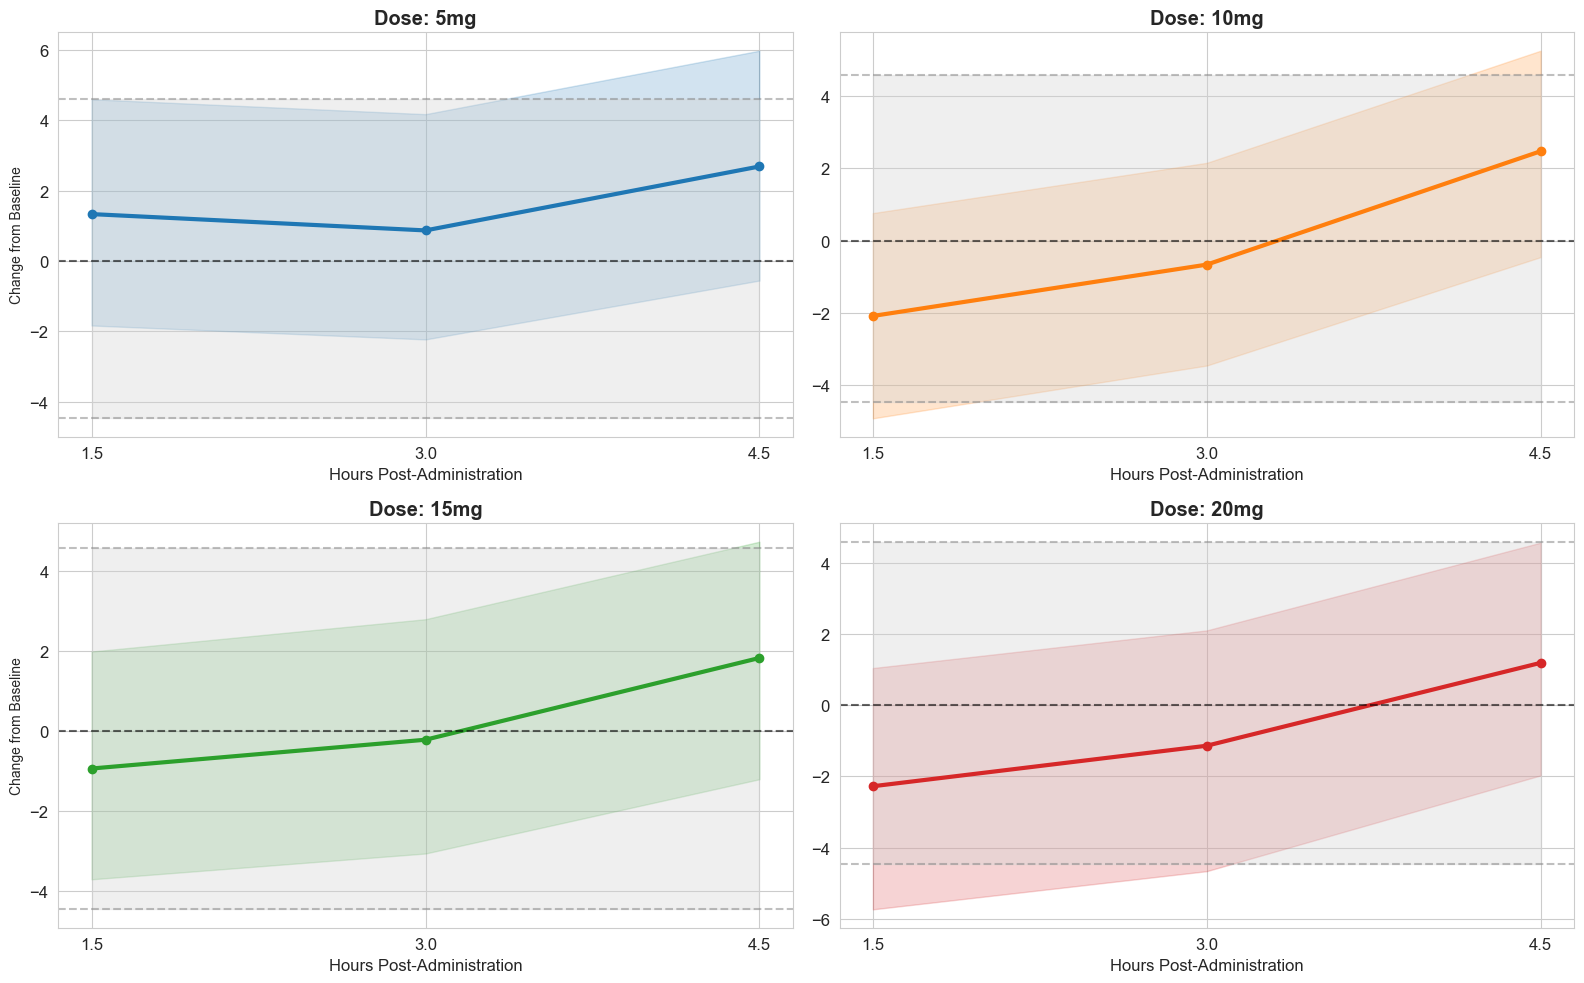

In [16]:
import matplotlib.pyplot as plt
import arviz as az
import re
import numpy as np





baseline_posterior_mean = trace.posterior['mu_baseline'].mean(dim=['chain', 'draw']).values

# Compute baseline HDI
baseline_hdi = az.hdi(trace.posterior['mu_baseline'], hdi_prob=0.95)


baseline_hdi_relative = baseline_hdi - baseline_posterior_mean
baseline_hdi_lower = baseline_hdi_relative['mu_baseline'][0].values
baseline_hdi_upper = baseline_hdi_relative['mu_baseline'][1].values


# # 3. Subtract the baseline mean from ALL cells to create a relative posterior
# relative_posterior = trace.posterior['mu_beta_cell'] - baseline_mean
posterior_dose = trace.posterior['mu_beta_dose']

# 2. Derive dose labels from coords['cell'] and sort numerically (small -> large)
def _dose_numeric_key(d):
    m = re.search(r"(\d+)", str(d))
    return int(m.group(1)) if m else float('inf')

cell_names = [str(c) for c in coords['dose_cell']]
dose_prefixes = sorted({re.split(r'[-_]', name)[0] for name in cell_names}, key=_dose_numeric_key)
# Limit to first 4 doses for the 2x2 grid (or change as needed)
doses = dose_prefixes[:4]

rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 5 * rows))
flat_axes = axes.flatten()

for i, dose in enumerate(doses):
    ax = flat_axes[i]

    # Cells that belong to this dose (robust to naming like '10mg_1.5h' or '10mg-3h')
    dose_cells = [c for c in coords['dose_cell'] if str(c).startswith(dose)]

    # Extract numeric hours robustly from the hour part of the cell name
    hours = []
    for c in dose_cells:
        name = str(c)
        if '-' in name:
            _, hour_part = name.split('-', 1)
        elif '_' in name:
            _, hour_part = name.split('_', 1)
        else:
            hour_part = '0h'
        m = re.search(r"([0-9]+(?:\.[0-9]+)?)", hour_part)
        hours.append(float(m.group(1)) if m else 0.0)
    hours = np.array(hours)

    if len(hours) == 0:
        ax.set_title(f'Dose: {dose}\nNo cells', fontsize=10)
        ax.set_xticks([])
        continue

    sort_idx = np.argsort(hours)
    sorted_hours = hours[sort_idx]
    sorted_cells = np.array(dose_cells, dtype=object)[sort_idx]

    # Select posterior samples for these cells and compute HDI + mean
    dose_samples = posterior_dose.sel(dose_cell=sorted_cells)
    hdi = az.hdi(dose_samples, hdi_prob=0.95)['mu_beta_dose'].values
    mean_vals = dose_samples.mean(dim=['chain', 'draw']).values

    # Plot credible interval and mean
    ax.fill_between(sorted_hours, hdi[:, 0], hdi[:, 1], color=f'C{i}', alpha=0.2)
    ax.plot(sorted_hours, mean_vals, color=f'C{i}', lw=3, marker='o')

    

    ax.axhline(0, color='black', linestyle='--', alpha=0.6)
  
    
    ax.axhline(baseline_hdi_lower, color='gray', linestyle='--', alpha=0.5, label='Baseline lower 95% HDI')
    ax.axhline(baseline_hdi_upper, color='gray', linestyle='--', alpha=0.5, label='Baseline upper 95% HDI')
    ax.set_title(f'Dose: {dose}', fontweight='bold')
    ax.set_xlabel('Hours Post-Administration')
    ax.set_xticks(sorted_hours)
    #print yaixis only on leftmost plots
    if i % cols == 0:
        ax.set_ylabel(f'Change from Baseline', fontsize=10)
    
    total_sd = np.sqrt(dose_samples.std(dim=['chain', 'draw'])**2 + 
                   trace.posterior['sigma_beta_dose'].sel(dose_cell=sorted_cells).mean(dim=['chain', 'draw'])**2)

   
    ax.fill_between(sorted_hours, baseline_hdi_lower, baseline_hdi_upper, color='lightgray', alpha=0.35, label='Baseline 95% HDI')



# Hide any unused axes (if fewer than 4 doses)
for j in range(len(doses), len(flat_axes)):
    flat_axes[j].set_visible(False)


#plt.suptitle(f'Relative Dose-Time Effects: Box and Block', fontsize=14)
plt.tight_layout()
plt.savefig('plots/Bayesian_mixed_model_dose_effects.png', dpi=300)
plt.show()

#### Box and Block modified

In [20]:
# import pymc as pm
# import arviz as az

# bayes_metric = 'Box and Block (modified)'

# bayes_cols = ['Subject', 'Timepoint', 'dose_mg', 'dose_hr', 'Condition', bayes_metric]
# bayes_df = bb_behavioural_results[bayes_cols].dropna(subset=[bayes_metric]).copy()
# if bayes_df.empty:
#     raise ValueError(f'No data available for {bayes_metric}.')

# bayes_df = bayes_df[bayes_df[bayes_metric] > 0].copy()
# if bayes_df.empty:
#     raise ValueError('All observations were zero; nothing to model.')

# bayes_df = bayes_df.sort_values(['Subject', 'dose_mg', 'dose_hr']).reset_index(drop=True)
# bayes_df['session_index'] = bayes_df.groupby('Subject').cumcount()

# subject_cat = pd.Categorical(bayes_df['Subject'])
# subject_idx = subject_cat.codes
# dose_series = bayes_df['dose_mg'].fillna(0).astype(int)
# dose_levels = sorted(dose_series.unique())
# nonzero_doses = [d for d in dose_levels if d != 0]

# dose_design = pd.get_dummies(dose_series).reindex(columns=nonzero_doses, fill_value=0).to_numpy(dtype=float)
# metric_values = bayes_df[bayes_metric].to_numpy(dtype=float)
# session_vals = bayes_df['session_index'].to_numpy(dtype=float)

# coords = {
#     'subject': subject_cat.categories,
#     'dose': [f'{d} mg' for d in nonzero_doses]
# }

# with pm.Model(coords=coords) as bayes_model_modified:
#     subject_idx_data = pm.Data('subject_idx', subject_idx)
#     session_vals_data = pm.Data('session_vals', session_vals)
#     dose_design_data = pm.Data('dose_design', dose_design)

#     # LogNormal parameters are on the log scale.
#     # mu=np.log(50) sets the median to 50. sigma=1.0 is a wide prior on the log scale.
#     mu_group = pm.LogNormal('mu_group', mu=np.log(30), sigma=np.log(10))
#     sigma_subject = pm.HalfNormal('sigma_subject', sigma=5.0)
#     subject_offset = pm.Normal('subject_offset', mu=0.0, sigma=1.0, dims='subject')
#     beta_session = pm.Normal('beta_session', mu=0.0, sigma=2.0)
#     beta_dose = pm.Normal('beta_dose', mu=0.0, sigma=2.0, dims='dose')
#     sigma = pm.HalfNormal('sigma', sigma=5.0)

#     mu = (
#         mu_group
#         + sigma_subject * subject_offset[subject_idx_data]
#         + beta_session * session_vals_data
#         + pm.math.dot(dose_design_data, beta_dose)
#     )

#     pm.Normal('obs', mu=mu, sigma=sigma, observed=metric_values)

#     bayes_trace = pm.sample(2000, tune=2000, target_accept=0.9, chains=4, random_seed=42)

# az_summary = az.summary(bayes_trace, var_names=['mu_group', 'beta_session', 'beta_dose', 'sigma_subject', 'sigma'])
# display(az_summary)

# prob_rows = []
# if 'beta_dose' in bayes_trace.posterior:
#     beta_samples = bayes_trace.posterior['beta_dose']
#     for i, dose_label in enumerate(coords['dose']):
#         vals = beta_samples.sel(dose=dose_label).values.reshape(-1)
#         prob_positive = float((vals > 0).mean())
#         prob_negative = float((vals < 0).mean())
#         prob_rows.append({
#             'dose_label': dose_label,
#             'Probability(beta_dose > 0)': prob_positive,
#             'Probability(beta_dose < 0)': prob_negative
#         })
#     dose_posterior_probs = pd.DataFrame(prob_rows)
#     display(dose_posterior_probs)
# else:
#     dose_posterior_probs = None

# az.plot_forest(bayes_trace, var_names=['beta_dose'], combined=True, figsize=(8, 4))
# plt.title('Posterior Dose Effects (Credible Intervals)')
# plt.show()

# az.plot_forest(bayes_trace, var_names=['beta_session'], combined=True, figsize=(6, 3))
# plt.title('Posterior Learning (Session) Effect')
# plt.show()

### Dose-response indentificaiton

Responder clusters (mean learning-adjusted residual per dose):


dose_mg,0,5,10,15,20
cluster,,,,,
0,-0.706039,1.62526,-1.094762,0.145455,-0.440606
1,-7.706397,0.00000,3.406734,2.576431,-3.642761



Cluster sizes:


,n_subjects
cluster,
0,10
1,3



Responder classification:


dose_mg,Subject,ResponderClass
0,HC01,Responder
1,HC02,Responder
2,HC03,Responder
3,HC04,Responder
4,HC05,Responder
5,HC06,Responder
6,HC08,Non-responder
7,HC09,Responder
8,HC10,Non-responder
9,HC11,Responder


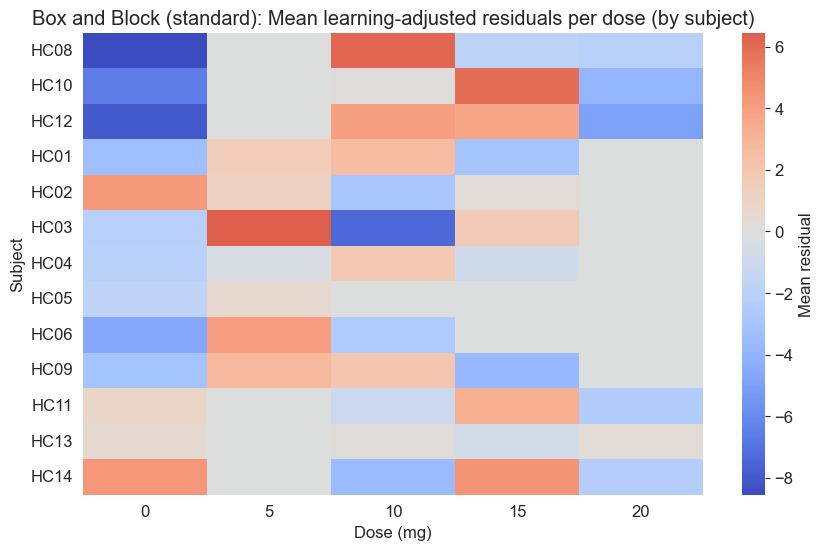

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

residual_data = adjusted_tables.get(primary_metric)
if residual_data is None or residual_data.empty:
    print('No learning-adjusted residuals available for responder identification.')
else:
    responder_df = residual_data.dropna(subset=['learning_adjusted']).copy()
    responder_df['dose_mg'] = responder_df['dose_mg'].fillna(0)

    if responder_df.empty:
        print('No usable residual observations (after filtering zeros and NaNs).')
    else:
        subject_features = responder_df.groupby(['Subject', 'dose_mg'])['learning_adjusted'].mean().reset_index()
        feature_matrix = subject_features.pivot(index='Subject', columns='dose_mg', values='learning_adjusted')
        dose_columns = feature_matrix.columns.tolist()
        feature_matrix = feature_matrix.fillna(0.0)

        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(feature_matrix)

        kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
        cluster_labels = kmeans.fit_predict(scaled_features)

        feature_matrix['cluster'] = cluster_labels
        cluster_summary = feature_matrix.groupby('cluster')[dose_columns].mean()
        cluster_sizes = feature_matrix['cluster'].value_counts().rename('n_subjects')

        mean_residual = cluster_summary.mean(axis=1)
        responder_cluster = mean_residual.idxmax()
        feature_matrix['ResponderClass'] = np.where(feature_matrix['cluster'] == responder_cluster, 'Responder', 'Non-responder')

        responder_table = feature_matrix[['ResponderClass']].reset_index()

        print('Responder clusters (mean learning-adjusted residual per dose):')
        display(cluster_summary)
        print('\nCluster sizes:')
        display(cluster_sizes.to_frame())
        print('\nResponder classification:')
        display(responder_table)

        plt.figure(figsize=(10, 6))
        heatmap_data = feature_matrix.sort_values('ResponderClass')[dose_columns]
        sns.heatmap(heatmap_data, cmap='coolwarm', center=0, cbar_kws={'label': 'Mean residual'})
        plt.title(f'{primary_metric}: Mean learning-adjusted residuals per dose (by subject)')
        plt.xlabel('Dose (mg)')
        plt.ylabel('Subject')
        plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_group, sigma_alpha, alpha_offset, beta1_group, sigma_beta1, beta1_offset, beta2_group, sigma_beta2, beta2_offset, beta3_group, sigma_beta3, beta3_offset, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 35 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_group,-0.875,1.188,-3.057,1.402,0.011,0.013,12273.0,6534.0,1.0
beta1_group,0.426,0.491,-0.514,1.334,0.006,0.005,6208.0,6147.0,1.0
beta2_group,-0.019,0.062,-0.133,0.101,0.001,0.001,6247.0,5949.0,1.0
beta3_group,-0.000,0.002,-0.004,0.004,0.000,0.000,6390.0,6328.0,1.0
sigma_alpha,0.452,0.351,0.000,1.077,0.004,0.005,6974.0,4094.0,1.0
sigma_beta1,0.055,0.046,0.000,0.137,0.001,0.001,5095.0,4497.0,1.0
sigma_beta2,0.004,0.003,0.000,0.009,0.000,0.000,5817.0,4468.0,1.0
sigma,5.666,0.339,5.039,6.288,0.003,0.004,16950.0,6028.0,1.0



Posterior probability that the max-dose effect is beneficial (per subject):


,Subject,Pr(effect @ max dose > 0),Effect_mean_at_max_dose
0,HC01,0.205750,-2.682975
1,HC02,0.221750,-2.429318
2,HC03,0.232125,-2.376455
3,HC04,0.250375,-2.147163
4,HC05,0.284375,-1.948143
5,HC06,0.249500,-2.437037
6,HC08,0.275375,-1.618397
7,HC09,0.188875,-2.975250
8,HC10,0.308000,-1.248628
9,HC11,0.290750,-1.361241


/var/folders/8l/lvwkyjcx0_z8571ry2j7g3nr0000gq/T/ipykernel_81047/1153994569.py:107: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_bounds = az.hdi(pred_array, hdi_prob=0.94)


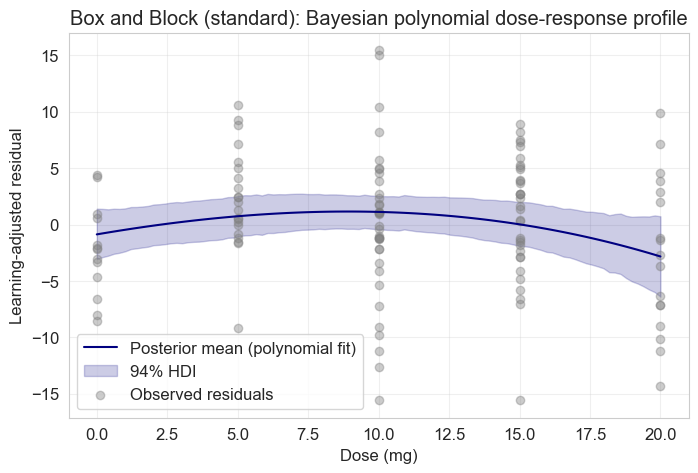

In [22]:
residual_data = adjusted_tables.get(primary_metric)
if residual_data is None or residual_data.empty:
    print('No learning-adjusted residuals available for dose-response modelling.')
else:
    dr_df = residual_data.dropna(subset=['learning_adjusted']).copy()
    dr_df['dose_mg'] = dr_df['dose_mg'].fillna(0)

    if dr_df.empty:
        print('No usable residual observations (after filtering zeros and NaNs).')
    else:
        subject_cat = pd.Categorical(dr_df['Subject'])
        subject_idx = subject_cat.codes
        dose_obs = dr_df['dose_mg'].astype(float).values
        dose_sq_obs = dose_obs ** 2
        dose_cu_obs = dose_obs ** 3
        resid_obs = dr_df['learning_adjusted'].values

        coords = {'subject': subject_cat.categories}

        with pm.Model(coords=coords) as dose_response_model:
            subject_idx_data = pm.Data('subject_idx', subject_idx)
            dose_data = pm.Data('dose', dose_obs)
            dose_sq_data = pm.Data('dose_sq', dose_sq_obs)
            dose_cu_data = pm.Data('dose_cu', dose_cu_obs)

            alpha_group = pm.Normal('alpha_group', mu=0.0, sigma=2.0)
            sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=1.0)
            alpha_offset = pm.Normal('alpha_offset', mu=0.0, sigma=1.0, dims='subject')
            alpha_subject = pm.Deterministic('alpha_subject', alpha_group + sigma_alpha * alpha_offset)

            beta1_group = pm.Normal('beta1_group', mu=0.0, sigma=1.0)
            sigma_beta1 = pm.HalfNormal('sigma_beta1', sigma=0.5)
            beta1_offset = pm.Normal('beta1_offset', mu=0.0, sigma=1.0, dims='subject')
            beta1_subject = pm.Deterministic('beta1_subject', beta1_group + sigma_beta1 * beta1_offset)

            beta2_group = pm.Normal('beta2_group', mu=0.0, sigma=0.2)
            sigma_beta2 = pm.HalfNormal('sigma_beta2', sigma=0.2)
            beta2_offset = pm.Normal('beta2_offset', mu=0.0, sigma=1.0, dims='subject')
            beta2_subject = pm.Deterministic('beta2_subject', beta2_group + sigma_beta2 * beta2_offset)

            beta3_group = pm.Normal('beta3_group', mu=0.0, sigma=0.2)
            sigma_beta3 = pm.HalfNormal('sigma_beta3', sigma=0.2)
            beta3_offset = pm.Normal('beta3_offset', mu=0.0, sigma=1.0, dims='subject')
            beta3_subject = pm.Deterministic('beta3_subject', beta3_group + sigma_beta3 * beta3_offset)

            sigma = pm.HalfNormal('sigma', sigma=1.5)
            mu = (
                alpha_subject[subject_idx_data]
                + beta1_subject[subject_idx_data] * dose_data
                + beta2_subject[subject_idx_data] * dose_sq_data
                + beta3_subject[subject_idx_data] * dose_cu_data
            )
            pm.Normal('obs', mu=mu, sigma=sigma, observed=resid_obs)

            dose_trace = pm.sample(2000, tune=2000, target_accept=0.9, random_state=42)

        summary = az.summary(
            dose_trace,
            var_names=[
                'alpha_group', 'beta1_group', 'beta2_group', 'beta3_group',
                'sigma_alpha', 'sigma_beta1', 'sigma_beta2', 'sigma'
            ]
        )
        display(summary)

        # Use .values to avoid xarray dimension mismatch (broadcasting) issues
        beta1_subject_vals = dose_trace.posterior['beta1_subject'].values
        beta2_subject_vals = dose_trace.posterior['beta2_subject'].values
        beta3_subject_vals = dose_trace.posterior['beta3_subject'].values
        max_dose = dr_df['dose_mg'].max()
        
        effect_samples_vals = (
            beta1_subject_vals * max_dose
            + beta2_subject_vals * (max_dose ** 2)
            + beta3_subject_vals * (max_dose ** 3)
        )
        
        # Average over chains (0) and draws (1)
        effect_prob = (effect_samples_vals > 0).mean(axis=(0, 1))
        effect_mean = effect_samples_vals.mean(axis=(0, 1))
        
        # Use the original categories for labels
        subject_labels = subject_cat.categories

        responder_probability = pd.DataFrame({
            'Subject': subject_labels,
            'Pr(effect @ max dose > 0)': effect_prob,
            'Effect_mean_at_max_dose': effect_mean
        })
        print('\nPosterior probability that the max-dose effect is beneficial (per subject):')
        display(responder_probability)

        dose_grid = np.linspace(0, dr_df['dose_mg'].max(), 100)
        dose_sq_grid = dose_grid ** 2
        posterior = dose_trace.posterior
        alpha_samples = posterior['alpha_group'].stack(sample=('chain', 'draw')).values
        beta1_samples = posterior['beta1_group'].stack(sample=('chain', 'draw')).values
        beta2_samples = posterior['beta2_group'].stack(sample=('chain', 'draw')).values
        beta3_samples = posterior['beta3_group'].stack(sample=('chain', 'draw')).values
        pred_array = (
            alpha_samples[:, None]
            + beta1_samples[:, None] * dose_grid[None, :]
            + beta2_samples[:, None] * dose_sq_grid[None, :]
            + beta3_samples[:, None] * (dose_grid[None, :] ** 3)
        )
        pred_mean = pred_array.mean(axis=0)
        hdi_bounds = az.hdi(pred_array, hdi_prob=0.94)

        dose_summary = pd.DataFrame({
            'dose_mg': dose_grid,
            'mean': pred_mean,
            'hdi_lower': hdi_bounds[:, 0],
            'hdi_upper': hdi_bounds[:, 1]
        })

        plt.figure(figsize=(8, 5))
        plt.plot(dose_summary['dose_mg'], dose_summary['mean'], color='navy', label='Posterior mean (polynomial fit)')
        plt.fill_between(
            dose_summary['dose_mg'],
            dose_summary['hdi_lower'],
            dose_summary['hdi_upper'],
            color='navy',
            alpha=0.2,
            label='94% HDI'
        )
        plt.scatter(dr_df['dose_mg'], dr_df['learning_adjusted'], color='gray', alpha=0.4, label='Observed residuals')
        plt.title(f'{primary_metric}: Bayesian polynomial dose-response profile')
        plt.xlabel('Dose (mg)')
        plt.ylabel('Learning-adjusted residual')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

## Save results to latex stats file

In [23]:
# --- Update Stats Data File ---
import re

def update_stats_data_file(trace_obj, output_file_path):
    """
    Updates the stats_data.txt file with Bayesian model results from the trace.
    Only updates variables that already exist in the file.
    """
    print(f"Updating {output_file_path} from Bayesian trace...")
    
    # 1. Generate Summary Dataframe
    # Using 95% HDI to match standard reporting
    try:
        summary_df = az.summary(trace_obj, var_names=['mu_baseline', 'beta_session', 'sigma_subject', 'mu_beta_dose', 'sigma_beta_dose'], hdi_prob=0.95)
    except Exception as e:
        print(f"Error generating summary from trace: {e}")
        return

    # Helper to format float to string_
    def to_str(val):
        return f"{val:.2f}"

    # Dictionary to hold the new commands -> value mappings
    # Key: LaTeX variable name (e.g. bayesBaseMean), Value: new content
    updates = {}

    # --- Fixed Parameters ---
    # Map index names from summary_df to variable prefixes in the text file
    try:
        if 'mu_baseline' in summary_df.index:
            updates['bayesBaseMean'] = to_str(summary_df.loc['mu_baseline', 'mean'])
            updates['bayesBaseHDILow'] = to_str(summary_df.loc['mu_baseline', 'hdi_2.5%'])
            updates['bayesBaseHDIHigh'] = to_str(summary_df.loc['mu_baseline', 'hdi_97.5%'])
            updates['bayesBaseHDI'] = f"[{updates['bayesBaseHDILow']}, {updates['bayesBaseHDIHigh']}]"

        if 'beta_session' in summary_df.index:
            updates['bayesSessionMean'] = to_str(summary_df.loc['beta_session', 'mean'])
            updates['bayesSessionHDILow'] = to_str(summary_df.loc['beta_session', 'hdi_2.5%'])
            updates['bayesSessionHDIHigh'] = to_str(summary_df.loc['beta_session', 'hdi_97.5%'])
            updates['bayesSessionHDI'] = f"[{updates['bayesSessionHDILow']}, {updates['bayesSessionHDIHigh']}]"

        if 'sigma_subject' in summary_df.index:
            updates['bayesSubjBaseSD'] = to_str(summary_df.loc['sigma_subject', 'mean'])
            updates['bayesSubjBaseHDILow'] = to_str(summary_df.loc['sigma_subject', 'hdi_2.5%'])
            updates['bayesSubjBaseHDIHigh'] = to_str(summary_df.loc['sigma_subject', 'hdi_97.5%'])
            updates['bayesSubjBaseHDI'] = f"[{updates['bayesSubjBaseHDILow']}, {updates['bayesSubjBaseHDIHigh']}]"
            
    except KeyError as e:
        print(f"Warning: Issue accessing fixed parameters: {e}")

    # --- Dose-Time Estimates ---
    # Map dose/time strings to file variable naming convention
    dose_token_map = {
        '5mg': 'FiveMg',
        '10mg': 'TenMg',
        '15mg': 'FifteenMg'
    }
    
    time_token_map = {
        '1.5': 'OneFive',
        '3': 'ThreeZero', 
        '4.5': 'FourFive'
    }

    # Iterate through summary rows to find mu_beta_dose[...] and sigma_beta_dose[...]
    for index_name in summary_df.index:
        param_type = None
        if index_name.startswith('mu_beta_dose['):
            param_type = 'Mean'
        elif index_name.startswith('sigma_beta_dose['):
            param_type = 'SD'
        
        if param_type:
            # Extract the cell name from brackets, e.g. "mu_beta_dose[5mg_1.5h]" -> "5mg_1.5h"
            match = re.search(r'\[(.*)\]', index_name)
            if match:
                cell_name = match.group(1)
                
                # Identify Dose
                dose_part = None
                for d_str, d_name in dose_token_map.items():
                    if d_str in cell_name:
                        dose_part = d_name
                        break
                
                # Identify Time
                time_part = None
                for t_str, t_name in time_token_map.items():
                    # Check for time string matching
                    if t_str in cell_name:
                         time_part = t_name
                         break
                
                if dose_part and time_part:
                    base_var_name = f"bayes{dose_part}{time_part}"
                    
                    mean_val = summary_df.loc[index_name, 'mean']
                    hdi_lo = summary_df.loc[index_name, 'hdi_2.5%']
                    hdi_hi = summary_df.loc[index_name, 'hdi_97.5%']
                    
                    if param_type == 'Mean':
                        updates[f"{base_var_name}Mean"] = to_str(mean_val)
                        updates[f"{base_var_name}HDILow"] = to_str(hdi_lo)
                        updates[f"{base_var_name}HDIHigh"] = to_str(hdi_hi)
                        updates[f"{base_var_name}HDI"] = f"[{to_str(hdi_lo)}, {to_str(hdi_hi)}]"
                    elif param_type == 'SD':
                        updates[f"{base_var_name}SD"] = to_str(mean_val)
                        updates[f"{base_var_name}SDHDILow"] = to_str(hdi_lo)
                        updates[f"{base_var_name}SDHDIHigh"] = to_str(hdi_hi)
                        updates[f"{base_var_name}SDHDI"] = f"[{to_str(hdi_lo)}, {to_str(hdi_hi)}]"

    # 2. Read and Update File
    try:
        with open(output_file_path, 'r') as f:
            content = f.read()
            
        count_updated = 0
        for var_name, new_value in updates.items():
            # Regex to find \newcommand{\varName}{oldValue}
            # We assume standard LaTeX formatting: \newcommand{\name}{value}
            # Safe escape for variable name
            escaped_var = re.escape(var_name)
            pattern = re.compile(r'(\\newcommand\{\\' + escaped_var + r'\}\{)(.*?)(\})')
            
            if pattern.search(content):
                # Use \g<1> and \g<3> to avoid ambiguity with numeric starts in new_value
                content = pattern.sub(r'\g<1>' + new_value + r'\g<3>', content)
                count_updated += 1
        
        # Write back
        with open(output_file_path, 'w') as f:
            f.write(content)
            
        print(f"Successfully updated {count_updated} variables in {output_file_path}")
        
    except FileNotFoundError:
        print(f"Error: File {output_file_path} not found.")

# Run the update using the 'trace' object from the Mixed Effects Model (Cell 25)
# Ensure this cell is run AFTER the model training cell.
if 'trace' in locals():
    update_stats_data_file(trace, 'stats_data.txt')
else:
    print("Error: 'trace' object not found. Please run the Bayesian Model cell first.")

Updating stats_data.txt from Bayesian trace...
Successfully updated 38 variables in stats_data.txt
